### What are the most demanded skills for the top 3 most popular data roles?

#### Methodology

1. Clean up skill column
2. Calculate skill count based on [job_title_short]
3. Calculate skill percentage
4. Plot final findings

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\tom-i\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_swe = df[df['job_country'] == 'Sweden']

In [4]:
df_skills = df_swe.explode('job_skills')

In [15]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
672,python,Data Engineer,1078
851,sql,Data Engineer,976
58,azure,Data Engineer,725
673,python,Data Scientist,636
48,aws,Data Engineer,548
...,...,...,...
29,assembly,Business Analyst,1
33,assembly,Machine Learning Engineer,1
34,assembly,Senior Data Engineer,1
36,atlassian,Cloud Engineer,1


In [19]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

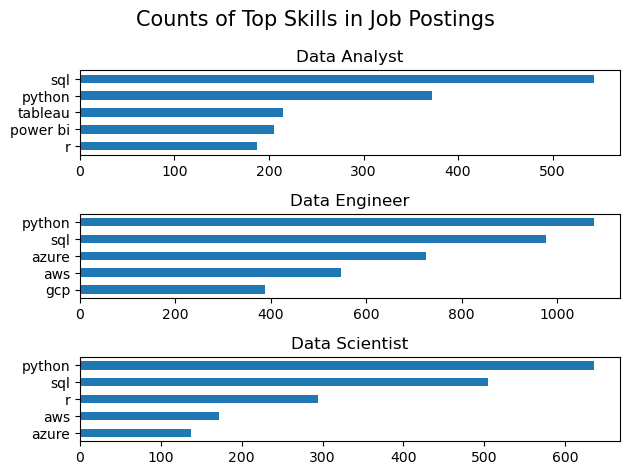

In [25]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    
fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout()
plt.show()

In [28]:
df_job_title_count = df_swe['job_title_short'].value_counts().reset_index(name='jobs_total')

In [35]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how= 'left', on='job_title_short')

df_skills_perc['skill_percent'] = 100 * (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) 


In [36]:
df_skills_perc


,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Engineer,1078,1757,61.354582
1,sql,Data Engineer,976,1757,55.549232
2,azure,Data Engineer,725,1757,41.263517
3,python,Data Scientist,636,1029,61.807580
4,aws,Data Engineer,548,1757,31.189528
...,...,...,...,...,...
1017,assembly,Business Analyst,1,444,0.225225
1018,assembly,Machine Learning Engineer,1,247,0.404858
1019,assembly,Senior Data Engineer,1,344,0.290698
1020,atlassian,Cloud Engineer,1,277,0.361011


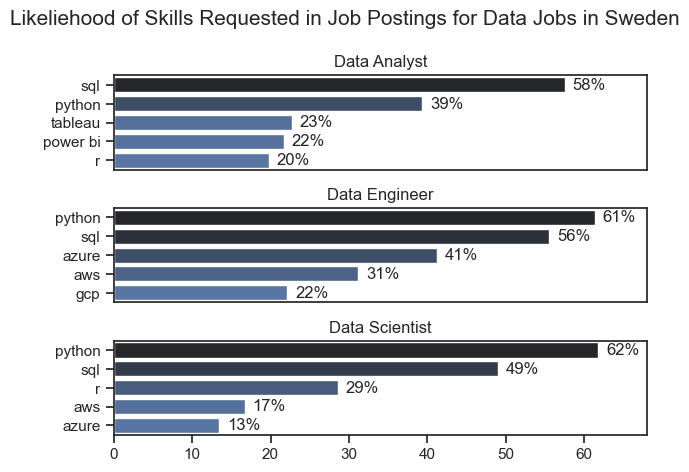

In [61]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    # df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 68)
    
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va = 'center')
        
    if i != len(job_titles) -1:
        ax[i].set_xticks([])
    
fig.suptitle('Likeliehood of Skills Requested in Job Postings for Data Jobs in Sweden', fontsize=15)
fig.tight_layout()
plt.show()